In [1]:
import pandas as pd

# 1. Chargement
path = "D:/IMDS/MALMO/IMU_LM_Data/data/merged_dataset/unified_dataset.parquet"
df = pd.read_parquet(path)

# 2. On définit les colonnes numériques (celles des capteurs)
sensor_cols = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

# 3. On n'applique l'interpolation QUE sur ces colonnes
df[sensor_cols] = df[sensor_cols].interpolate(method='linear')

# 4. Pour les colonnes de texte, on utilise le "remplissage vers l'avant/arrière" 
# (car on ne peut pas interpoler du texte, mais on peut copier le nom de l'activité précédente)
df = df.fillna(method='bfill').fillna(method='ffill')

# 5. Vérification
print("Nombre de NaN restants :", df.isna().sum().sum())

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Théo Lassale/Desktop/Perso/Stage/Stage_Malmö/IMU_LM_Data/data/merged_dataset/filtered_activities_dataset.parquet'

In [2]:
import numpy as np

WINDOW_SIZE = 100  # 2 secondes à 50 Hz
STRIDE = 50        # overlap 50%

features = ["acc_x","acc_y","acc_z","gyro_x","gyro_y","gyro_z"]

X = []
labels = []

group_cols = ["dataset", "subject_id", "session_id"]

for _, group in df.groupby(group_cols):
    data = group.sort_values("timestamp_ns")

    signals = data[features].values
    acts = data["global_activity_id"].values

    for i in range(0, len(signals) - WINDOW_SIZE, STRIDE):
        window = signals[i:i+WINDOW_SIZE]

        # label majoritaire dans la fenêtre
        label = np.bincount(acts[i:i+WINDOW_SIZE]).argmax()

        X.append(window)
        labels.append(label)

X = np.array(X)
labels = np.array(labels)

from sklearn.utils import shuffle
X, labels = shuffle(X, labels, random_state=42)

print(X.shape)  # (n_samples, 100, 6)

# On calcule la moyenne et l'écart-type sur l'ensemble du dataset 
# pour chaque axe (acc_x, acc_y, etc.)
X_mean = np.mean(X, axis=(0, 1)) 
X_std = np.std(X, axis=(0, 1))

# Application de la formule : (Valeur - Moyenne) / Écart-Type
X = (X - X_mean) / (X_std + 1e-7) 

print(f"Moyenne après normalisation : {np.mean(X):.3f}") # Devrait être proche de 0
print(f"Écart-type après normalisation : {np.std(X):.3f}") # Devrait être proche de 1

NameError: name 'df' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

timesteps = X.shape[1]
n_features = X.shape[2]
latent_dim = 32

# ===== ENCODER =====
inputs = layers.Input(shape=(timesteps, n_features))

x = layers.Conv1D(latent_dim, 5, activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(64, 5, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(256, 5, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(1024, 5, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(3000, 5, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling1D()(x)

latent = layers.Dense(latent_dim)(x)

encoder = Model(inputs, latent)

# ===== DECODER =====
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense((timesteps // 4) * 3000, activation='relu')(latent_inputs)
x = layers.Reshape((timesteps // 4, 3000))(x)

x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(1024, 5, activation='relu', padding='same')(x)

x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(256, 5, activation='relu', padding='same')(x)

x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(64, 5, activation='relu', padding='same')(x)

outputs = layers.Conv1D(n_features, 5, activation='linear', padding='same')(x)

decoder = Model(latent_inputs, outputs)

autoencoder = Model(inputs, decoder(encoder(inputs)))
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=4,          
    restore_best_weights=True  
)

# Utiliser le callback dans le fit
autoencoder.fit(
    X, X,
    epochs=50,    
    batch_size=256,
    shuffle=True,
    validation_split=0.1,
    callbacks=[early_stop] 
)

Epoch 1/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - loss: 0.4958 - val_loss: 0.4033
Epoch 2/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - loss: 0.3781 - val_loss: 0.3475
Epoch 3/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.3269 - val_loss: 0.3002
Epoch 4/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.2811 - val_loss: 0.2604
Epoch 5/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - loss: 0.2543 - val_loss: 0.2464
Epoch 6/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - loss: 0.2387 - val_loss: 0.2325
Epoch 7/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.2278 - val_loss: 0.2259
Epoch 8/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.2201 - val_loss: 0.2239
Epoch 9/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.2142 - val_loss: 0.2159
Epoch 10/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.2085 - val_loss: 0.2140
Epoch 11/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.2043 - val_loss: 0.2105
Epoch 12/100
742/74

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


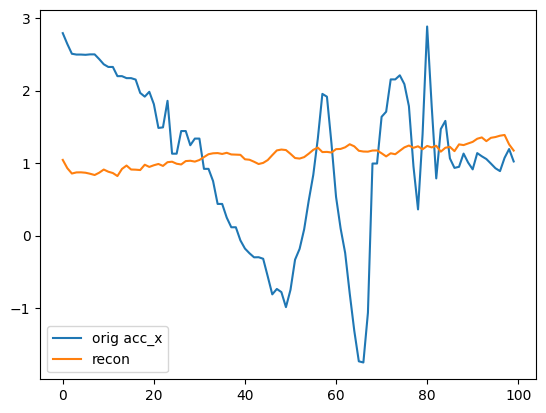

In [ ]:
import matplotlib.pyplot as plt

i = 0
orig = X[i]
recon = autoencoder.predict(X[i:i+1])[0]

plt.plot(orig[:,0], label="orig acc_x")
plt.plot(recon[:,0], label="recon")
plt.legend()
plt.show()

In [ ]:
import umap.umap_ as umap

latent_vectors = encoder.predict(X[:10000])  # sample pour vitesse

reducer = umap.UMAP(n_components=2)
embedding = reducer.fit_transform(latent_vectors)

c:\Users\Théo Lassale\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


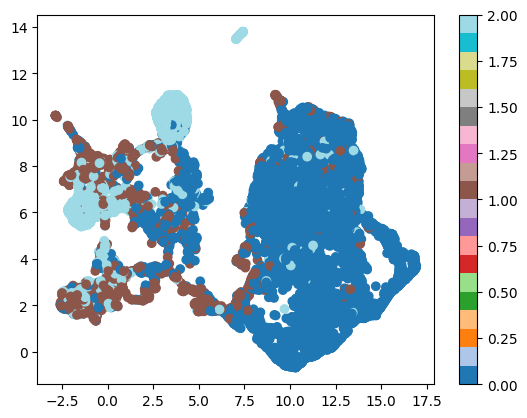

In [ ]:
plt.scatter(embedding[:,0], embedding[:,1], c=labels[:10000], cmap='tab20')
plt.colorbar()
plt.show()